Author: Chris J. Dallmann \
Affiliation: University of Wuerzburg \
Last revision: 17-March-2026

In [33]:
# Load libraries
from navis.models import TraversalModel
import networkx as nx
import numpy as np
import pandas as pd
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

In [2]:
# Settings
data_dir = r'../data/'
syn_thresh = 5

In [36]:
# Load connectivity 
df_connectivity = pd.read_csv(data_dir + 'flywire_v783_connections.csv')
df_connectivity = df_connectivity.rename(columns={"pre_pt_root_id": "pre_root_id", "post_pt_root_id": "post_root_id"}, errors="raise")
    
# Load neuron classifications 
df_class = pd.read_csv(data_dir + 'flywire_v783_classifications.csv')

# Load neurons of interest
df_neurons_of_interest = pd.read_csv(data_dir + 'neurons_of_interest.csv')

In [4]:
# Sum synapses across neuropils
df_connectivity = df_connectivity.groupby(['pre_root_id','post_root_id'])['syn_count'].sum().reset_index(name='syn_count').sort_values(by=['syn_count'], ascending=False).reset_index(drop=True)

In [5]:
# Remove connections between neurons smaller than syn_thresh 
df_connectivity = df_connectivity[df_connectivity.syn_count>=syn_thresh]

In [6]:
# Get IDs
pre_root_ids = df_connectivity.pre_root_id.unique().tolist()
post_root_ids = df_connectivity.post_root_id.unique().tolist()
all_ids = list(np.unique(np.array(pre_root_ids+post_root_ids)))

In [7]:
# Create dictionary that maps root ID to index 
# Graph traversal model (below) requires indices instead of IDs
dict_id_to_index = {}
for index, i in enumerate(all_ids):
    dict_id_to_index[i] = index

In [8]:
# Add indices to dataframe 
df_connectivity["pre_index"] = df_connectivity["pre_root_id"].map(lambda x: dict_id_to_index[x])
df_connectivity["post_index"] = df_connectivity["post_root_id"].map(lambda x: dict_id_to_index[x])

In [9]:
# Build network graph 
G = nx.DiGraph() 

# Add nodes
G.add_nodes_from(df_connectivity.pre_index.unique().tolist())
G.add_nodes_from(df_connectivity.post_index.unique().tolist())

In [10]:
# Generate dictionary with total number of inputs per node
n_inputs = {}
for node in tqdm(G.nodes):
    n_inputs[node] = df_connectivity.syn_count[df_connectivity.post_index==node].sum()

100%|█████████████████████████████████████████████████████████████████████████| 138584/138584 [03:49<00:00, 604.84it/s]


In [11]:
# Add edges as input fractions 
for index, row in tqdm(df_connectivity.iterrows(), total=np.size(df_connectivity,axis=0)): 
    G.add_edge(df_connectivity.pre_index[index], 
               df_connectivity.post_index[index], 
               weight=df_connectivity.syn_count[index]/n_inputs[df_connectivity.post_index[index]])

100%|█████████████████████████████████████████████████████████████████████| 3732460/3732460 [02:53<00:00, 21496.39it/s]


In [12]:
# Get edges
edges = nx.to_pandas_edgelist(G)

In [13]:
# Get see IDs
#df_class_of_interest = df_class[(df_class['class']=='visual')]
df_class_of_interest = df_class[(df_class['super_class']=='visual_projection')]
seed_ids = df_class_of_interest.root_id.unique().tolist()
len(seed_ids)

7665

In [14]:
# Display sub classes
df_class_of_interest.sub_class.unique()

array([nan, 'circadian_clock', 'ocellar_interneuron'], dtype=object)

In [15]:
# Remove seed IDs that have no outputs
pre_root_ids = df_connectivity.pre_root_id.unique().tolist()
seed_ids = [(i) for i in seed_ids if i in pre_root_ids]
print(len(seed_ids))

7657


In [16]:
# Get seed nodes
seed_nodes = [dict_id_to_index[i] for i in seed_ids if i in dict_id_to_index]
len(seed_nodes)

7657

In [17]:
# Generate graph traversal model
model = TraversalModel(edges, seeds=seed_nodes)

In [18]:
# Run model
t = time.time()
model.run_parallel(n_cores=6, iterations=10000)
elapsed = time.time() - t

In [29]:
# Show elapsed time
print(round(elapsed,1))

2483.2


In [51]:
# Show unique layers
# model.summary.layer_median.unique().tolist()

In [48]:
# Find specific nodes based on root ID
# Note: Seed neurons are layer 1, so subtract -1 for layer downstream of seed neurons 
root_ids = df_neurons_of_interest.connectome_id[df_neurons_of_interest.community_name=='RRN'].tolist() + \
           df_neurons_of_interest.connectome_id[df_neurons_of_interest.community_name.str.contains('BPN')].tolist()

for root_id in root_ids:
    print(root_id)
    dict_layer[root_id] = model.summary.layer_mean[model.summary.node==dict_id_to_index[root_id]].item()

In [25]:
# # Get all nodes of a given layer
# layer_idx = model.summary.node[model.summary.layer_median==1.0].tolist()

# # Create dictionary that maps index to root ID 
# dict_index_to_id = {v: k for k, v in dict_id_to_index.items()}

# # Get IDs 
# layer_ids = [dict_index_to_id[i] for i in layer_idx if i in dict_index_to_id]

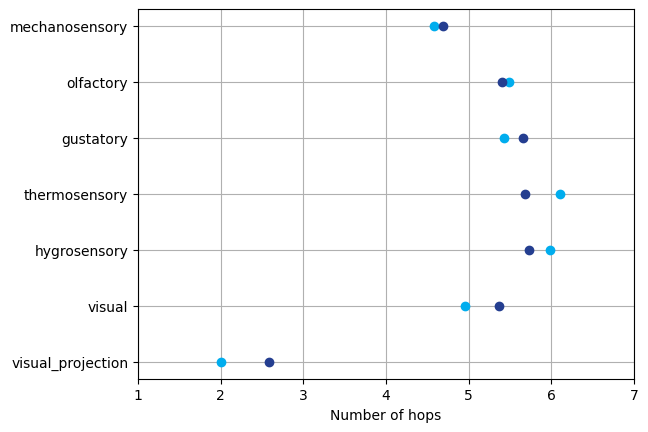

In [35]:
# Plot hops from seed neurons
seed_classes = ['mechanosensory','olfactory','gustatory','thermosensory','hygrosensory','visual','visual_projection']
hops_RRN = [4.58, 5.49, 5.43, 6.10, 5.99, 4.96, 2.00]
hops_BPN = [4.69, 5.40, 5.66, 5.68, 5.73, 5.37, 2.59]

fig, ax = plt.subplots()
plt.plot(hops_BPN, range(len(seed_classes)), 'o', color=[36/255,62/255,144/255,1])
plt.plot(hops_RRN, range(len(seed_classes)), 'o', color=[0/255,173/255,238/255,1])
ax.set_yticks(range(len(seed_classes)))
ax.set_yticklabels(seed_classes)
plt.xlim([1,7])
plt.grid()
plt.gca().invert_yaxis()
plt.xlabel('Number of hops')
# plt.savefig(r'C:\Users\Chris\Desktop\figure.eps')
plt.show()